## Reinforcement Learning Strategy for Algorithmic Trading

In [1]:
# Importing the libraries
from sentiment_lib import *

# Parameters
time_window = 60
ticker = "NVDA"
model = 'rppo'
base_path = "sentiment"

In [2]:
# Importing the datasets
train_df = pd.read_csv(f"rl_dfs/train/{ticker}_sentiment.csv", index_col=0)
train_df.index = pd.to_datetime(train_df.index)

test_df = pd.read_csv(f"rl_dfs/test/{ticker}_sentiment.csv", index_col=0)
test_df.index = pd.to_datetime(test_df.index)

# Number of steps for each iteration
num_of_steps = train_df.shape[0] - time_window
print(f"Number of steps: {num_of_steps}")

Number of steps: 73633


In [3]:
# Parameters for training environment
train_kwargs = {
    "data": train_df,
    "ticker":ticker, 
    "time_window":time_window,
    "trade_cost":0,
    "reward_logic":"log_position",
    "reward_scale":1E4,
    "only_long":False,
    "verbose":False
}

# Parameters for testing environment
test_kwargs = {
    "data": test_df,
    "ticker":ticker, 
    "time_window":time_window,
    "trade_cost":0,
    "reward_logic":"log_position",
    "reward_scale":1E4,
    "only_long":False,
    "verbose":False
}

# Model parameters
model_parameters = {
    'n_steps': 60,
    'gamma': 0.995,
    'ent_coef': 0.005,
    'learning_rate': 0.0003,
    "batch_size": 60
}

# Policy parameters
policy_kwargs = dict(
    net_arch=[dict(vf=[128, 128, 128], pi=[128, 128])],
    lstm_hidden_size=256,
    n_lstm_layers=2
)



In [4]:
# Creating the pipeline and its processes
mt = MultiProcessingPipeline(ticker=ticker,
                            train_kwargs=train_kwargs, 
                             test_kwargs=test_kwargs,
                             n_process=3,
                             model=model,
                             base_path=base_path)

now = datetime.now()
mt.create_process_conditions(model_parameters, 
                             policy_parameters=policy_kwargs,
                             policy="MultiInputLstmPolicy", 
                             total_timesteps = num_of_steps*3)


Creating process  0

Creating process  1

Creating process  2


In [5]:
today = now.strftime("%Y%m%d")
now_str = f"{now.hour}h{now.minute}"
log_paths = os.path.join(RESULTS_DIR, base_path, ticker,today, now_str, model)
tensorboard_command = f"tensorboard --logdir {log_paths} --port 6006"

print("source .venv/bin/activate")
print(tensorboard_command)

source .venv/bin/activate
tensorboard --logdir results/sentiment/NVDA/20250301/5h53/rppo --port 6006


In [6]:
# Training and testing the model
start = datetime.now()
mt.multi_tasking()

print(f"Training and testing time: {datetime.now() - start}")

Exception in thread Thread-9 (train_test_individual_model):
Traceback (most recent call last):
  File "/home/guilherme/.pyenv/versions/3.11.11/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/guilherme/Documentos/IC/.venv/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/home/guilherme/.pyenv/versions/3.11.11/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/guilherme/Documentos/IC/sentiment_lib/multi_process_pipeline.py", line 158, in train_test_individual_model
    trained = agent.train_model(model, saving_dir, total_timesteps)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/guilherme/Documentos/IC/sentiment_lib/agents/DRL_agent.py", line 75, in train_model
    model = model.learn(
            ^^^^^^^^^^^^
  File "/home/guilherme/Documentos/IC/.venv/lib/python3.11/site-packages/sb3_cont

Successfully load model results/sentiment/NVDA/20250301/05h53/rppo_1/agent_rppo.zip
Successfully load model results/sentiment/NVDA/20250301/05h53/rppo_0/agent_rppo.zip
Training and testing time: 5:39:24.459835



Results of process 1

==== Final Metrics ====
Total Return : 0.66
Sharpe Ratio : -0.07
Max Drawdown : 0.27
Hit Ratio : 0.44


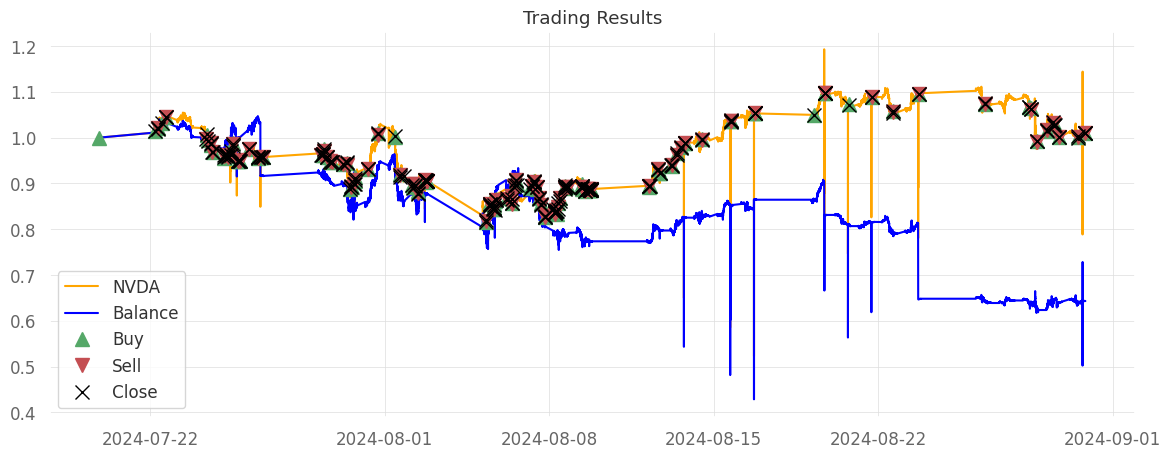


Results of process 0

==== Final Metrics ====
Total Return : 3.49
Sharpe Ratio : 0.09
Max Drawdown : 0.82
Hit Ratio : 0.50


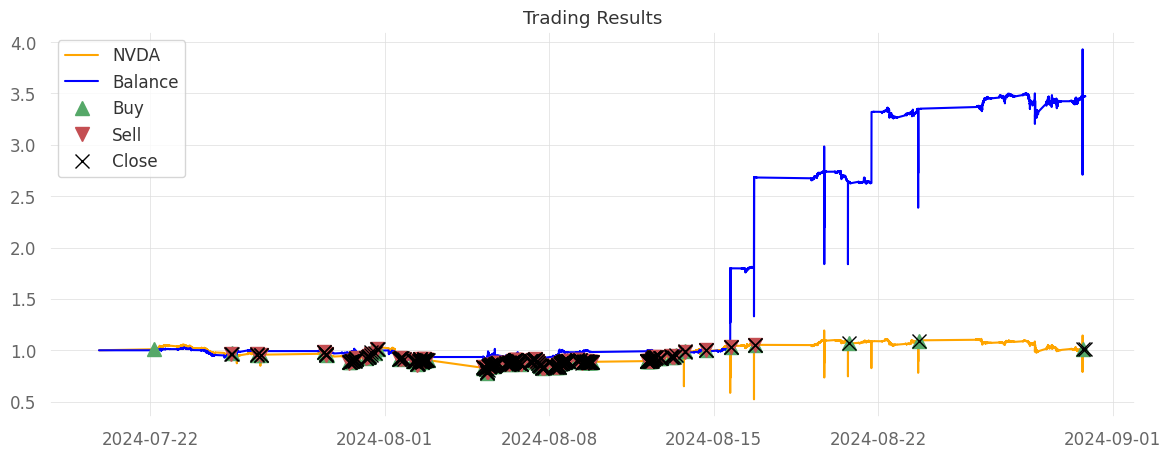

In [7]:
# Getting the results
mt.get_results()